#  Exploratory Data Analysis (EDA)

##  Objective
Comprehensive statistical analysis and visualization of collected financial news data.

### Analysis Goals:
- **Temporal Patterns**: How does news volume change over time?
- **Coverage Analysis**: Which companies get the most coverage?
- **Content Statistics**: Article length, word count distributions
- **Source Distribution**: Coverage across news sources
- **Quality Metrics**: Data completeness, consistency

### Industry Context:
Hedge funds analyze news patterns to identify:
- **News clusters** (multiple articles = important event)
- **Coverage gaps** (under-reported companies)
- **Source bias** (reliability differences)

In [1]:
# Standard Libraries
import pandas as pd
import numpy as np
from datetime import datetime
import json
from pathlib import Path
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Set random seed for reproducibility
np.random.seed(42)

##  Load Processed Data

In [2]:
# Define paths
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / '01_DATA'
PROCESSED_DIR = DATA_DIR / 'processed'
RESULTS_DIR = BASE_DIR / '03_RESULTS'
VIZ_DIR = RESULTS_DIR / 'visualizations'
METRICS_DIR = RESULTS_DIR / 'metrics'

# Create output directories
VIZ_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print(f" Base Directory: {BASE_DIR}")
print(f" Data Directory: {PROCESSED_DIR}")
print(f" Results Directory: {RESULTS_DIR}")

 Base Directory: c:\Users\HARSHIT\Desktop\p\nlp analysis
 Data Directory: c:\Users\HARSHIT\Desktop\p\nlp analysis\01_DATA\processed
 Results Directory: c:\Users\HARSHIT\Desktop\p\nlp analysis\03_RESULTS


In [3]:
# Load the most recent processed data file
parquet_files = list(PROCESSED_DIR.glob('*.parquet'))

if parquet_files:
    # Get the most recent file
    latest_file = max(parquet_files, key=lambda p: p.stat().st_mtime)
    print(f" Loading: {latest_file.name}")
    df = pd.read_parquet(latest_file)
    print(f" Loaded {len(df):,} articles")
else:
    print("  No parquet files found. Please run Notebook 01 first.")
    df = pd.DataFrame()

# Display basic info
if not df.empty:
    print(f"\n Dataset Shape: {df.shape}")
    print(f"\n Columns: {list(df.columns)}")
    print(f"\n  Date Range: {df['date'].min()} to {df['date'].max()}")

 Loading: processed_news_20260118_1810.parquet
 Loaded 63 articles

 Dataset Shape: (63, 11)

 Columns: ['date', 'title', 'text', 'source', 'url', 'ticker', 'publisher', 'query', 'article_length', 'word_count', 'collection_date']

  Date Range: 2025-09-26 07:00:00 to 2026-01-18 12:19:48


##  1. Temporal Analysis

In [4]:
# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['hour'] = df['date'].dt.hour
df['date_only'] = df['date'].dt.date

# Articles per day
daily_counts = df.groupby('date_only').size().reset_index(name='article_count')

# Articles per month
df['year_month'] = df['date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size().reset_index(name='article_count')

print(" Temporal features extracted")
print(f"\n Time Series Statistics:")
print(f"  - Total days covered: {daily_counts['date_only'].nunique()}")
print(f"  - Average articles per day: {daily_counts['article_count'].mean():.1f}")
print(f"  - Max articles in a day: {daily_counts['article_count'].max()}")
print(f"  - Min articles in a day: {daily_counts['article_count'].min()}")

 Temporal features extracted

 Time Series Statistics:
  - Total days covered: 20
  - Average articles per day: 3.1
  - Max articles in a day: 12
  - Min articles in a day: 1


In [5]:
# Visualization: Articles over time
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Daily Article Volume', 'Monthly Article Volume'),
    vertical_spacing=0.12
)

# Daily trend
fig.add_trace(
    go.Scatter(
        x=daily_counts['date_only'],
        y=daily_counts['article_count'],
        mode='lines',
        name='Daily',
        line=dict(color='#1f77b4', width=1)
    ),
    row=1, col=1
)

# Monthly trend
fig.add_trace(
    go.Bar(
        x=[str(p) for p in monthly_counts['year_month']],
        y=monthly_counts['article_count'],
        name='Monthly',
        marker_color='#2ca02c'
    ),
    row=2, col=1
)

fig.update_layout(
    height=800,
    title_text='Temporal Patterns in Financial News Coverage',
    showlegend=False
)

fig.update_xaxes(title_text='Date', row=1, col=1)
fig.update_xaxes(title_text='Month', row=2, col=1)
fig.update_yaxes(title_text='Article Count', row=1, col=1)
fig.update_yaxes(title_text='Article Count', row=2, col=1)

# Save
fig.write_html(VIZ_DIR / 'temporal_patterns.html')
fig.show()

print(f" Saved: temporal_patterns.html")

 Saved: temporal_patterns.html


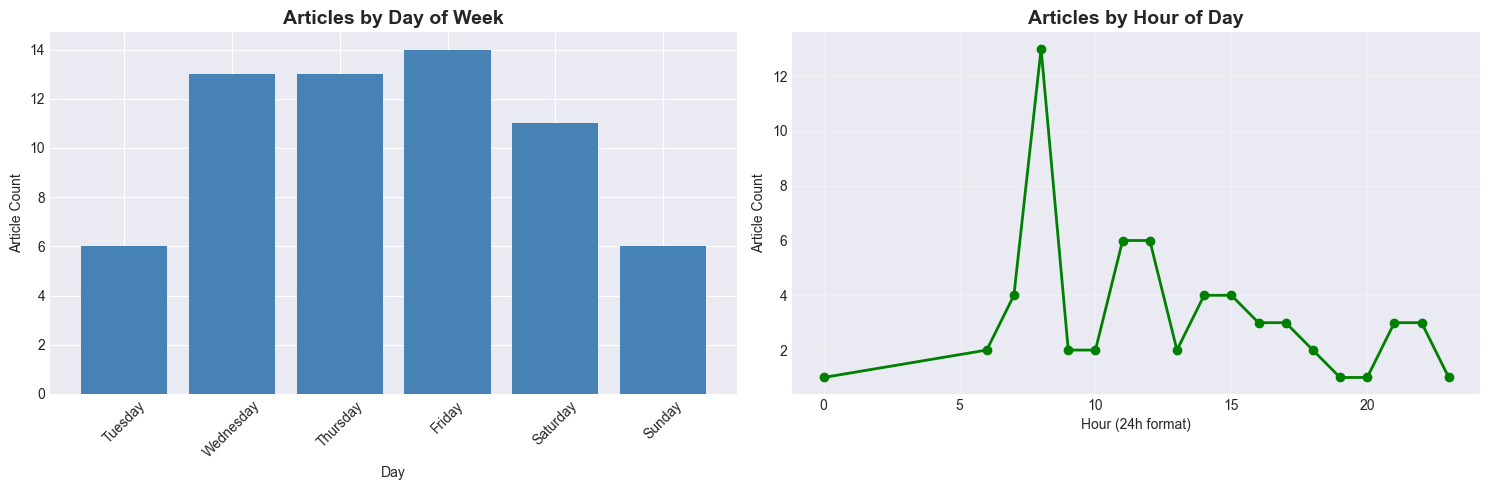

 Saved: temporal_patterns_detailed.png

 Peak Publishing Times:
  - Busiest day: Friday
  - Slowest day: Tuesday
  - Peak hour: 8:00


In [6]:
# Day of week analysis
dow_counts = df.groupby('day_of_week').size().reset_index(name='count')
dow_counts['day_name'] = dow_counts['day_of_week'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

# Hour of day analysis
hour_counts = df.groupby('hour').size().reset_index(name='count')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day of week
axes[0].bar(dow_counts['day_name'], dow_counts['count'], color='steelblue')
axes[0].set_title('Articles by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Article Count')
axes[0].tick_params(axis='x', rotation=45)

# Hour of day
axes[1].plot(hour_counts['hour'], hour_counts['count'], marker='o', color='green', linewidth=2)
axes[1].set_title('Articles by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (24h format)')
axes[1].set_ylabel('Article Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'temporal_patterns_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Saved: temporal_patterns_detailed.png")

print(f"\n Peak Publishing Times:")
print(f"  - Busiest day: {dow_counts.loc[dow_counts['count'].idxmax(), 'day_name']}")
print(f"  - Slowest day: {dow_counts.loc[dow_counts['count'].idxmin(), 'day_name']}")
print(f"  - Peak hour: {hour_counts.loc[hour_counts['count'].idxmax(), 'hour']}:00")

##  2. Company Coverage Analysis

In [7]:
# Company mention frequency
ticker_counts = df['ticker'].value_counts().head(30)

print(f" Company Coverage Statistics:")
print(f"  - Unique companies: {df['ticker'].nunique()}")
print(f"  - Most covered: {ticker_counts.index[0]} ({ticker_counts.values[0]:,} articles)")
print(f"  - Least covered: {ticker_counts.index[-1]} ({ticker_counts.values[-1]:,} articles)")
print(f"  - Average per company: {df.groupby('ticker').size().mean():.1f} articles")

# Visualize top companies
fig = px.bar(
    x=ticker_counts.values,
    y=ticker_counts.index,
    orientation='h',
    title='Top 30 Companies by News Coverage',
    labels={'x': 'Article Count', 'y': 'Ticker'},
    color=ticker_counts.values,
    color_continuous_scale='Viridis'
)

fig.update_layout(
    height=800,
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}
)

fig.write_html(VIZ_DIR / 'top_ticker_mentions.html')
fig.show()

print(f" Saved: top_ticker_mentions.html")

 Company Coverage Statistics:
  - Unique companies: 19
  - Most covered: ABT (7 articles)
  - Least covered: AEP (1 articles)
  - Average per company: 3.3 articles


 Saved: top_ticker_mentions.html


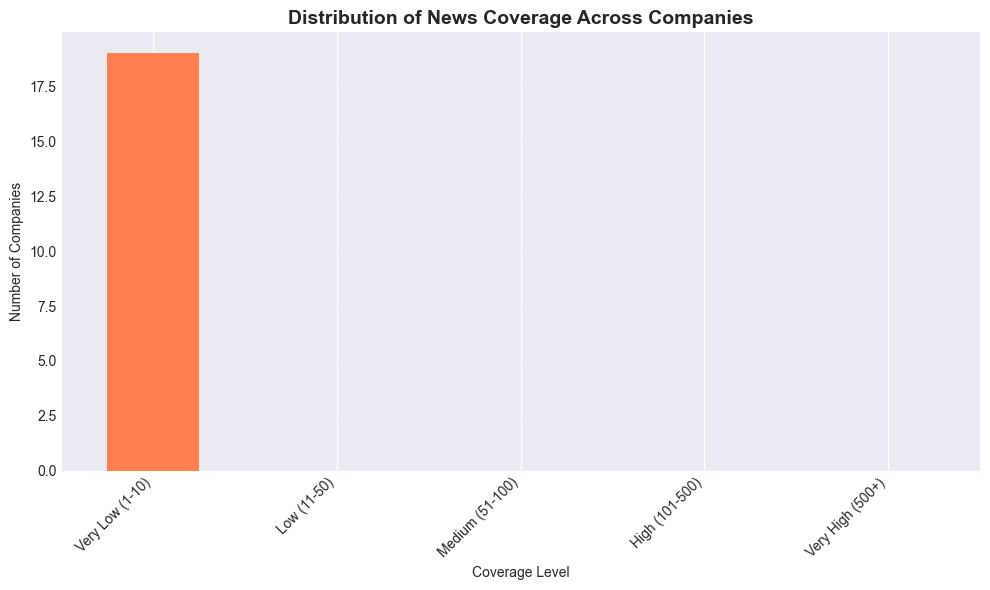

 Saved: coverage_distribution.png

 Coverage Distribution:
coverage_level
Very Low (1-10)     19
Low (11-50)          0
Medium (51-100)      0
High (101-500)       0
Very High (500+)     0
Name: count, dtype: int64


In [8]:
# Coverage distribution by ticker
coverage_dist = df.groupby('ticker').size().reset_index(name='article_count')

# Create bins for coverage levels
coverage_dist['coverage_level'] = pd.cut(
    coverage_dist['article_count'],
    bins=[0, 10, 50, 100, 500, float('inf')],
    labels=['Very Low (1-10)', 'Low (11-50)', 'Medium (51-100)', 'High (101-500)', 'Very High (500+)']
)

coverage_summary = coverage_dist['coverage_level'].value_counts().sort_index()

# Visualize
plt.figure(figsize=(10, 6))
coverage_summary.plot(kind='bar', color='coral')
plt.title('Distribution of News Coverage Across Companies', fontsize=14, fontweight='bold')
plt.xlabel('Coverage Level')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(VIZ_DIR / 'coverage_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Saved: coverage_distribution.png")
print(f"\n Coverage Distribution:")
print(coverage_summary)

##  3. Source Distribution Analysis

In [9]:
# Source statistics
source_counts = df['source'].value_counts()

print(f" Source Distribution:")
for source, count in source_counts.items():
    pct = (count / len(df)) * 100
    print(f"  - {source}: {count:,} articles ({pct:.1f}%)")

# Visualize source distribution
fig = go.Figure(data=[go.Pie(
    labels=source_counts.index,
    values=source_counts.values,
    hole=0.4,
    marker=dict(colors=px.colors.qualitative.Set3)
)])

fig.update_layout(
    title='News Source Distribution',
    height=600
)

fig.write_html(VIZ_DIR / 'source_distribution.html')
fig.show()

print(f" Saved: source_distribution.html")

 Source Distribution:
  - Google News: 63 articles (100.0%)


 Saved: source_distribution.html


##  4. Content Statistics

In [10]:
# Calculate content statistics
print(f" Content Statistics:")
print(f"\n Article Length:")
print(f"  - Mean: {df['article_length'].mean():.0f} characters")
print(f"  - Median: {df['article_length'].median():.0f} characters")
print(f"  - Std Dev: {df['article_length'].std():.0f} characters")
print(f"  - Min: {df['article_length'].min()} characters")
print(f"  - Max: {df['article_length'].max()} characters")

print(f"\n Word Count:")
print(f"  - Mean: {df['word_count'].mean():.0f} words")
print(f"  - Median: {df['word_count'].median():.0f} words")
print(f"  - Std Dev: {df['word_count'].std():.0f} words")
print(f"  - Min: {df['word_count'].min()} words")
print(f"  - Max: {df['word_count'].max()} words")

 Content Statistics:

 Article Length:
  - Mean: 116 characters
  - Median: 111 characters
  - Std Dev: 23 characters
  - Min: 100 characters
  - Max: 267 characters

 Word Count:
  - Mean: 15 words
  - Median: 14 words
  - Std Dev: 4 words
  - Min: 11 words
  - Max: 37 words


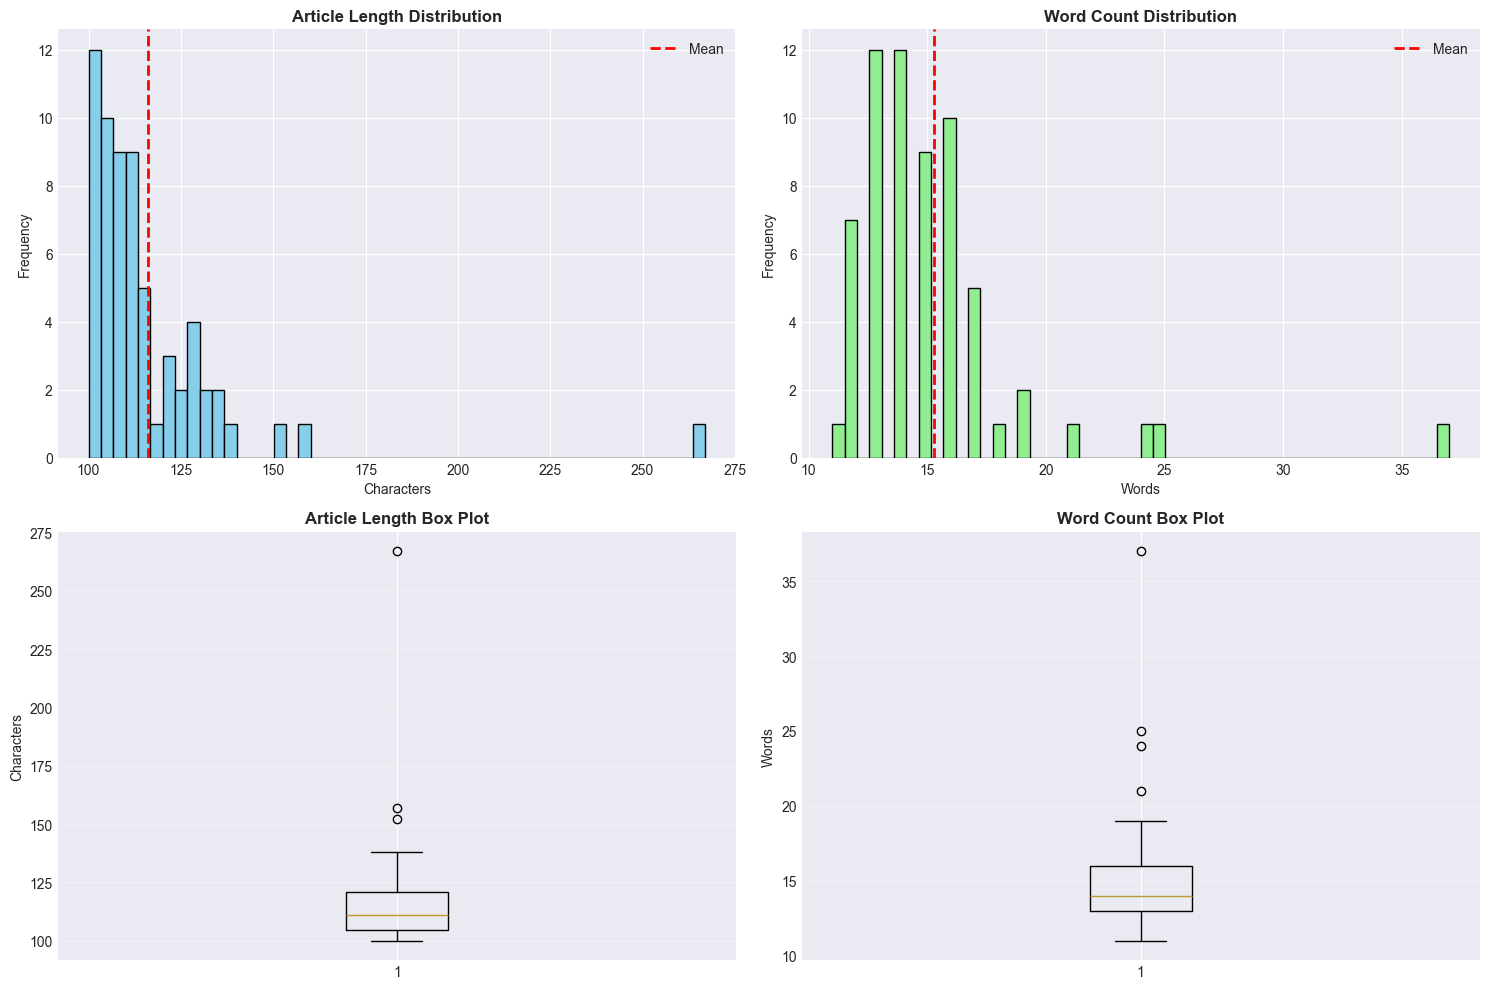

 Saved: content_statistics.png


In [11]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Article length histogram
axes[0, 0].hist(df['article_length'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Article Length Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['article_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].legend()

# Word count histogram
axes[0, 1].hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].legend()

# Article length boxplot
axes[1, 0].boxplot(df['article_length'], vert=True)
axes[1, 0].set_title('Article Length Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Characters')
axes[1, 0].grid(axis='y', alpha=0.3)

# Word count boxplot
axes[1, 1].boxplot(df['word_count'], vert=True)
axes[1, 1].set_title('Word Count Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Words')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'content_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Saved: content_statistics.png")

##  5. Data Quality Report

In [12]:
# Comprehensive quality report
quality_report = {
    'total_records': len(df),
    'unique_tickers': df['ticker'].nunique(),
    'unique_sources': df['source'].nunique(),
    'date_range': {
        'start': str(df['date'].min()),
        'end': str(df['date'].max()),
        'days': (df['date'].max() - df['date'].min()).days
    },
    'completeness': {
        'title': f"{(1 - df['title'].isna().mean()) * 100:.2f}%",
        'text': f"{(1 - df['text'].isna().mean()) * 100:.2f}%",
        'date': f"{(1 - df['date'].isna().mean()) * 100:.2f}%",
        'ticker': f"{(1 - df['ticker'].isna().mean()) * 100:.2f}%",
        'source': f"{(1 - df['source'].isna().mean()) * 100:.2f}%"
    },
    'content_stats': {
        'avg_article_length': int(df['article_length'].mean()),
        'avg_word_count': int(df['word_count'].mean()),
        'median_article_length': int(df['article_length'].median()),
        'median_word_count': int(df['word_count'].median())
    },
    'temporal_stats': {
        'avg_articles_per_day': float(daily_counts['article_count'].mean()),
        'max_articles_per_day': int(daily_counts['article_count'].max()),
        'min_articles_per_day': int(daily_counts['article_count'].min())
    },
    'coverage_stats': {
        'top_5_tickers': ticker_counts.head(5).to_dict(),
        'avg_articles_per_ticker': float(df.groupby('ticker').size().mean())
    }
}

# Save quality report
with open(METRICS_DIR / 'eda_quality_report.json', 'w') as f:
    json.dump(quality_report, f, indent=2)

print(" Saved: eda_quality_report.json")
print(f"\n Quality Report Summary:")
print(json.dumps(quality_report, indent=2))

 Saved: eda_quality_report.json

 Quality Report Summary:
{
  "total_records": 63,
  "unique_tickers": 19,
  "unique_sources": 1,
  "date_range": {
    "start": "2025-09-26 07:00:00",
    "end": "2026-01-18 12:19:48",
    "days": 114
  },
  "completeness": {
    "title": "100.00%",
    "text": "100.00%",
    "date": "100.00%",
    "ticker": "100.00%",
    "source": "100.00%"
  },
  "content_stats": {
    "avg_article_length": 116,
    "avg_word_count": 15,
    "median_article_length": 111,
    "median_word_count": 14
  },
  "temporal_stats": {
    "avg_articles_per_day": 3.15,
    "max_articles_per_day": 12,
    "min_articles_per_day": 1
  },
  "coverage_stats": {
    "top_5_tickers": {
      "ABT": 7,
      "AVGO": 6,
      "BABA": 6,
      "BAC": 5,
      "APA": 4
    },
    "avg_articles_per_ticker": 3.3157894736842106
  }
}


##  6. Comprehensive Summary Statistics

In [13]:
# Generate comprehensive statistics
summary_stats = {
    'overview': {
        'total_articles': len(df),
        'unique_companies': df['ticker'].nunique(),
        'date_span_days': (df['date'].max() - df['date'].min()).days,
        'sources': df['source'].nunique()
    },
    'article_length_stats': df['article_length'].describe().to_dict(),
    'word_count_stats': df['word_count'].describe().to_dict(),
    'temporal': {
        'earliest_article': str(df['date'].min()),
        'latest_article': str(df['date'].max()),
        'busiest_day': str(dow_counts.loc[dow_counts['count'].idxmax(), 'day_name']),
        'peak_hour': int(hour_counts.loc[hour_counts['count'].idxmax(), 'hour'])
    },
    'coverage': {
        'most_covered_ticker': ticker_counts.index[0],
        'most_covered_count': int(ticker_counts.values[0]),
        'least_covered_ticker': ticker_counts.index[-1],
        'least_covered_count': int(ticker_counts.values[-1])
    }
}

# Save summary statistics
with open(METRICS_DIR / 'eda_summary_stats.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(" Saved: eda_summary_stats.json")
print(f"\n Summary Statistics:")
print(json.dumps(summary_stats, indent=2))

 Saved: eda_summary_stats.json

 Summary Statistics:
{
  "overview": {
    "total_articles": 63,
    "unique_companies": 19,
    "date_span_days": 114,
    "sources": 1
  },
  "article_length_stats": {
    "count": 63.0,
    "mean": 116.0952380952381,
    "std": 23.10335423609579,
    "min": 100.0,
    "25%": 104.5,
    "50%": 111.0,
    "75%": 121.0,
    "max": 267.0
  },
  "word_count_stats": {
    "count": 63.0,
    "mean": 15.26984126984127,
    "std": 3.823553275660967,
    "min": 11.0,
    "25%": 13.0,
    "50%": 14.0,
    "75%": 16.0,
    "max": 37.0
  },
  "temporal": {
    "earliest_article": "2025-09-26 07:00:00",
    "latest_article": "2026-01-18 12:19:48",
    "busiest_day": "Friday",
    "peak_hour": 8
  },
  "coverage": {
    "most_covered_ticker": "ABT",
    "most_covered_count": 7,
    "least_covered_ticker": "AEP",
    "least_covered_count": 1
  }
}
